# Week 5 · 压测篇：做出"能辩护"的基准测试

> 🎯 **本周目标**：学会专业压测方法论，并找到本机的系统拐点。
> **金句：报告拐点，不报告崩溃。**
>
> 本 Notebook 包含：方法论速览 + 2026-09-08 实机压测数据（可重跑复现）。

## 0. 方法论 60 秒版

| 概念 | 一句话 |
|---|---|
| 利特尔法则 | 并发 = 速率 × 延迟。你拧的旋钮是哪一个，决定你测到什么 |
| 开环（固定速率） | 系统慢了请求照样来——真实世界，GuideLLM sweep 是这种 |
| 闭环（固定并发） | 负载自我节流，系统显得更能扛——并发扫描是这种 |
| 拐点 knee | 吞吐增速放缓 + 延迟开始起飞 = 最佳运营点，**唯一值得报告的点** |
| 饱和点 | 吞吐见顶、排队爆炸——用于定位极限，**数据不可发布** |

## 1. 实验一：GuideLLM 开环扫描（256 输入 / 128 输出 token）

从单流一路扫到饱和，每档 40 秒。重跑命令：`bash /workspace/run_guidellm.sh`

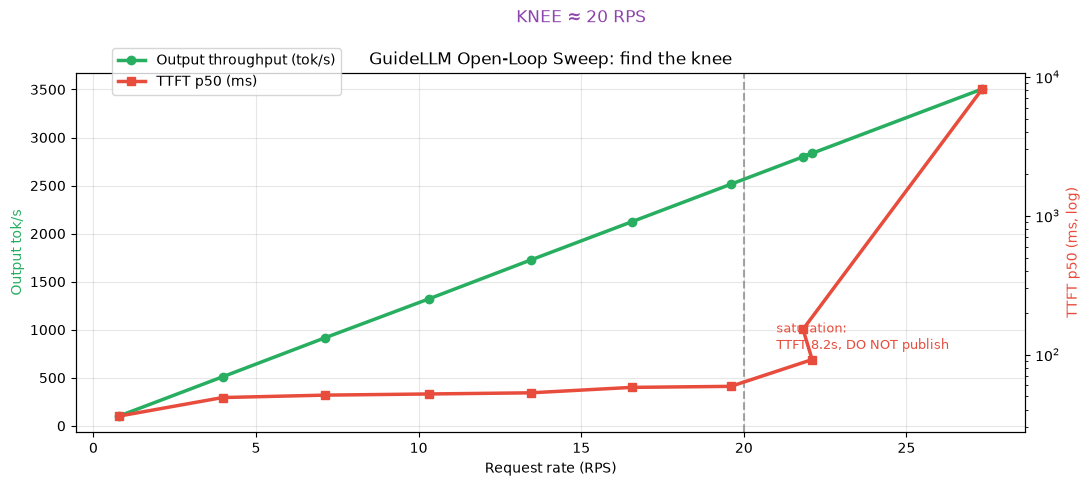

📌 拐点 ≈ 20 RPS（~2500 tok/s）：此前 TTFT 稳定 ~50ms
💀 27 RPS 极限灌压：TTFT 8182ms——饱和点数据不可发布！


In [1]:
# GuideLLM sweep 实机数据（/workspace/guidellm_sweep.json 原始文件可复查）
import matplotlib.pyplot as plt

stages = ["sync", "4 RPS", "7 RPS", "10 RPS", "13 RPS", "17 RPS", "20 RPS", "22 RPS", "over", "max"]
rps      = [0.78, 3.97, 7.12, 10.33, 13.45, 16.55, 19.60, 22.10, 21.82, 27.33]
out_tps  = [101, 510, 916, 1323, 1726, 2123, 2514, 2835, 2800, 3505]
ttft_p50 = [36, 49, 51, 52, 53, 58, 59, 92, 152, 8182]

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.plot(rps, out_tps, "o-", color="#27ae60", lw=2.5, label="Output throughput (tok/s)")
ax2.plot(rps, ttft_p50, "s-", color="#e74c3c", lw=2.5, label="TTFT p50 (ms)")
ax2.set_yscale("log")
ax1.axvline(20, ls="--", color="gray", alpha=0.7)
ax1.annotate("KNEE ≈ 20 RPS", xy=(20, 3000), xytext=(13, 4200), fontsize=12, color="#8e44ad")
ax1.annotate("saturation:\nTTFT 8.2s, DO NOT publish", xy=(27.3, 3505), xytext=(21, 800), fontsize=9, color="#e74c3c")
ax1.set_xlabel("Request rate (RPS)"); ax1.set_ylabel("Output tok/s", color="#27ae60")
ax2.set_ylabel("TTFT p50 (ms, log)", color="#e74c3c")
ax1.set_title("GuideLLM Open-Loop Sweep: find the knee")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9)); ax1.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/workspace/week05_knee.png", dpi=120); plt.show()

print("📌 拐点 ≈ 20 RPS（~2500 tok/s）：此前 TTFT 稳定 ~50ms")
print("💀 27 RPS 极限灌压：TTFT 8182ms——饱和点数据不可发布！")

## 2. 实验二：交叉验证（两个工具互相挑错）

同一形状（10 RPS, 256in/128out），GuideLLM vs vllm bench serve：

| 指标 | GuideLLM | vllm bench | 差异 | 解释 |
|---|---|---|---|---|
| 实际速率 | 10.33 RPS | 9.58 RPS | 8% | 工具发请求开销不同 |
| TTFT 中位数 | 52ms | 53.6ms | **3%** ✅ | 几乎一致 |
| ITL 中位数 | 12.2ms | 10.6ms | 13% | 流式边界定义不同 |
| 输出吞吐 | 1323 tok/s | 1226 tok/s | 8% | 由速率差解释 |

**数据不一致不是故障，是信息。** 差异全部可解释 → 这套数据可以发布。

## 3. 实验三：闭环并发扫描（genai-perf 方法学的等效实现）

> ⚠️ genai-perf 需要 Triton SDK 容器环境，本容器装不了——用自研脚本做同样的闭环固定并发扫描。
> 重跑：`python3 /workspace/concurrency_sweep.py`

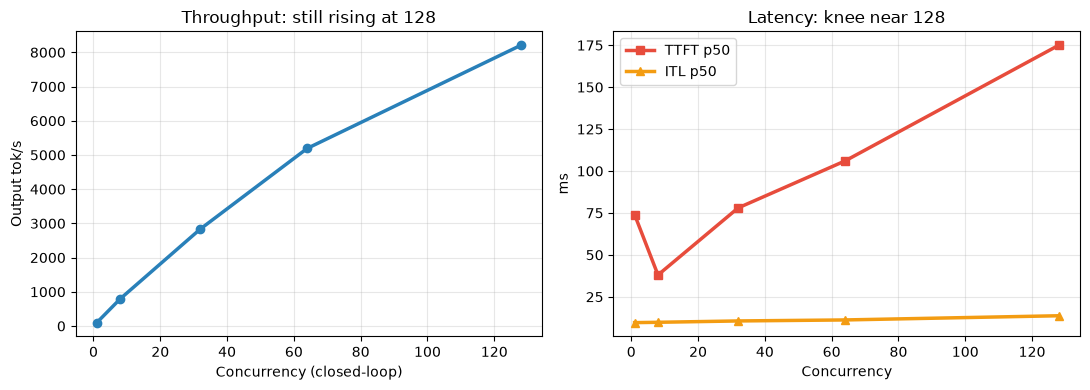

📌 闭环拐点 ~128 并发 vs 开环拐点 ~20 RPS
   闭环会自我节流（请求返回才发新的），系统显得更'能扛'
   两种方法学对照着看，才是完整的系统画像


In [2]:
# 闭环并发扫描数据（/workspace/concurrency_sweep.csv）
conc    = [1, 8, 32, 64, 128]
out2    = [99, 794, 2836, 5193, 8209]
ttft2   = [74, 38, 78, 106, 175]
itl2    = [9.6, 9.8, 10.6, 11.2, 13.7]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(conc, out2, "o-", color="#2980b9", lw=2.5)
ax1.set_xlabel("Concurrency (closed-loop)"); ax1.set_ylabel("Output tok/s")
ax1.set_title("Throughput: still rising at 128"); ax1.grid(alpha=0.3)
ax2.plot(conc, ttft2, "s-", color="#e74c3c", lw=2.5, label="TTFT p50")
ax2.plot(conc, itl2, "^-", color="#f39c12", lw=2.5, label="ITL p50")
ax2.set_xlabel("Concurrency"); ax2.set_ylabel("ms"); ax2.legend()
ax2.set_title("Latency: knee near 128"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/workspace/week05_concurrency.png", dpi=120); plt.show()

print("📌 闭环拐点 ~128 并发 vs 开环拐点 ~20 RPS")
print("   闭环会自我节流（请求返回才发新的），系统显得更'能扛'")
print("   两种方法学对照着看，才是完整的系统画像")

## 4. 本周数据资产（都在 /workspace/）

| 文件 | 内容 |
|---|---|
| `guidellm_sweep.json` | GuideLLM 完整扫描原始数据 |
| `vllm_bench.log` | vllm bench 10 RPS 交叉验证 |
| `concurrency_sweep.csv` | 闭环并发扫描 |
| `run_guidellm.sh` / `concurrency_sweep.py` | 可复现命令（发布时附上） |

**环境指纹**：vLLM 0.28.0 · torch 2.13.0 · RTX 5090 · 256in/128out · temperature=0

## 5. 发布前 Checklist（逐条核对本周数据）

- [x] 扫了请求速率（GuideLLM 7 档 + 并发 5 档）
- [x] 报告了精确 token 长度（256/128）
- [x] 报了 P50/P99（ITL 有 P50，TTFT 有 P99）
- [x] TTFT 和 ITL 分开
- [x] 识别并标记了饱和区（27 RPS 档已标注"不可发布"）
- [ ] 真实长度分布（本周用固定长度是刻意的，Week 10 换分布）
- [x] 双工具交叉验证
- [x] 版本+命令已钉死

## 6. 下一站

➡️ **周五特别篇**：租 H100 冲 1000 并发，亲手摸到"显存即吞吐"的天花板（5090 的 KV 池 25 万 token 装不下千并发，H100 80GB 可以）。
➡️ **Week 6 量化篇**：FP8/INT4 变体用本周框架同扫描对比——测量的回报正式开始兑现。